In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "/home/jovyan/sirf-demo/.packages")
import stir_simind_utils as utils
# plotting settings
plt.ion() # interactive 'on' such that plots appear during loops
#%% Import SIRF
import sirf.STIR as spect
spect.set_verbosity(0)
import numpy as np
from simind_python_connector import StirSimindAdaptor
import phantomgen as phantom
import numpy as np
from pathlib import Path
demo_path = Path("/home/jovyan/sirf-demo/icf_calculation")

## SPECT Image Reconstruction

The scatter-corrected projection data generated in the previous steps are now reconstructed using **SIRF/STIR**.

We will perform an **OSEM (Ordered Subsets Expectation Maximisation)** reconstruction incorporating:

- **attenuation correction** using the phantom attenuation map;
- **collimator-detector response / resolution modelling**;
- a **Poisson log-likelihood** objective function.

The reconstruction parameters and system model are defined explicitly, allowing the reconstruction pipeline to be inspected and modified.

In [23]:
# Select the dataset to reconstruct
sim_dir = demo_path / "lu177_128"
#sim_dir = demo_path / "tc99m_128"

# Photopeak emission projection data
tomo_em = sim_dir / "tomo" / "lu177_simulation_em_noisy.hs"
#tomo_em = sim_dir / "tomo" / "tc99m_simulation_em_noisy.hs"

# Scatter-corrected projection data
tomo_cor = sim_dir / "tomo" / "lu177_simulation_tew.hs"
#tomo_cor = sim_dir / "tomo" / "tc99m_simulation_dew.hs"

# Scatter projection data
tomo_sca = sim_dir / "tomo" / "lu177_simulation_tew_scatter.hs"
#tomo_sca = sim_dir / "tomo" / "tc99m_simulation_dew_scatter.hs"

# Attenuation map
ctac = sim_dir / "input" / "cyl_lu_ctac.hv"
#ctac = sim_dir / "input" / "cyl_tc_ctac.hv"

mask_arr = np.load("/home/jovyan/sirf-demo/icf_calculation/tc99m_128/input/mask_tc.npy")
gt_act_arr = spect.ImageData("/home/jovyan/sirf-demo/icf_calculation/lu177_128/input/cyl_lu_act.hv").as_array()
#gt_act_arr = spect.ImageData("/home/jovyan/sirf-demo/icf_calculation/tc99m_128/input/cyl_tc_act.hv").as_array()


In [24]:
# Load scatter-corrected projection data
acquisition_data = spect.AcquisitionData(str(tomo_cor))

# Reconstruction image geometry
matrix_size = (128,) * 3
voxel_size = (4.42,) * 3

# OSEM parameters
subiterations = 100
subsets = 2
save_interval = 10

name_prefix = "lu177_sim"
#name_prefix = "tc99m_sim"

# Load attenuation map
attenuation_map = spect.ImageData(str(ctac))

keep_views_in_cache = True

# Create a template for the reconstructed image
initial_image = spect.ImageData(acquisition_data)
initial_image.initialise(matrix_size, vsize=voxel_size)
initial_image.set_modality("NM")

# Uniform initial estimate
initial_image.fill(1)

## Configure the SPECT System Model

The **acquisition model** describes how an activity distribution in image space produces SPECT projection data.

A `SPECTUBMatrix` is used to model the SPECT imaging system. The model includes two important physical effects:

- **Attenuation** — spatially varying photon attenuation is modelled using the attenuation map.
- **Collimator-detector response** — the distance-dependent loss of spatial resolution is represented using a parameterised resolution model.

The resolution model is defined by an intrinsic Gaussian width (`sigma_0`) and a distance-dependent component (`slope`).

The resulting system matrix is used by SIRF/STIR's ray-tracing acquisition model during iterative reconstruction.

In [25]:
# Reconstruction output
recon_type = "osem"
recon_dir = sim_dir / "recons" / recon_type
recon_dir.mkdir(parents=True, exist_ok=True)

# Create the SPECT system matrix
acq_model_matrix = spect.SPECTUBMatrix()

# Optionally cache projection views to speed up reconstruction
acq_model_matrix.set_keep_all_views_in_cache(keep_views_in_cache)


# -------------------------------------------------------------------------
# Attenuation correction
# -------------------------------------------------------------------------

# The attenuation map is currently flipped to account for the image
# orientation expected by this STIR configuration.
flipped_attenuation_map = attenuation_map.clone()
flipped_attenuation_map.fill(
    np.flip(attenuation_map.as_array(), axis=2)
)

acq_model_matrix.set_attenuation_image(flipped_attenuation_map)


# -------------------------------------------------------------------------
# Acquisition model
# -------------------------------------------------------------------------

am = spect.AcquisitionModelUsingMatrix(acq_model_matrix)

# Configure the model for the measured projections and image geometry
am.set_up(acquisition_data, initial_image)

# Create the Poisson log-likelihood objective function
obj_fun = spect.make_Poisson_loglikelihood(acquisition_data)

# Associate it with the SPECT acquisition model
obj_fun.set_acquisition_model(am)

# Create the image that will be updated during reconstruction
reconstructed_image = initial_image.clone()

# Configure the OSEM reconstructor
recon = spect.OSMAPOSLReconstructor()

recon.set_num_subiterations(subiterations)
recon.set_num_subsets(subsets)

# Save intermediate reconstruction results
recon.set_save_interval(save_interval)
recon.enable_output()
recon.set_output_filename_prefix(str(recon_dir / f"{name_prefix}_{recon_type}"))

# Set the objective function
recon.set_objective_function(obj_fun)

# Initialise and run the reconstruction
recon.set_up(reconstructed_image)
recon.reconstruct(reconstructed_image)

icf_osem = np.sum(reconstructed_image.as_array() * mask_arr) / np.sum(gt_act_arr * mask_arr) #cnts/MBq
print("ICF (OSEM) =", icf_osem) #cnts/MBq

ICF (OSEM) = 109.264725


In [26]:
# Reconstruction output
recon_type = "osem_rm"
recon_dir = sim_dir / "recons" / recon_type
recon_dir.mkdir(parents=True, exist_ok=True)

# Parameters for the distance-dependent resolution model
sigma_0 = 2.35598  # mm
slope = 0.01771

# Create the SPECT system matrix
acq_model_matrix = spect.SPECTUBMatrix()

# Optionally cache projection views to speed up reconstruction
acq_model_matrix.set_keep_all_views_in_cache(keep_views_in_cache)


# -------------------------------------------------------------------------
# Attenuation correction
# -------------------------------------------------------------------------

# The attenuation map is currently flipped to account for the image
# orientation expected by this STIR configuration.
flipped_attenuation_map = attenuation_map.clone()
flipped_attenuation_map.fill(
    np.flip(attenuation_map.as_array(), axis=2)
)

acq_model_matrix.set_attenuation_image(flipped_attenuation_map)


# -------------------------------------------------------------------------
# Resolution modelling
# -------------------------------------------------------------------------

acq_model_matrix.set_resolution_model(
    float(sigma_0),
    float(slope),
    full_3D=False
)


# -------------------------------------------------------------------------
# Acquisition model
# -------------------------------------------------------------------------

am = spect.AcquisitionModelUsingMatrix(acq_model_matrix)

# Configure the model for the measured projections and image geometry
am.set_up(acquisition_data, initial_image)

# Create the Poisson log-likelihood objective function
obj_fun = spect.make_Poisson_loglikelihood(acquisition_data)

# Associate it with the SPECT acquisition model
obj_fun.set_acquisition_model(am)

# Create the image that will be updated during reconstruction
reconstructed_image = initial_image.clone()

# Configure the OSEM reconstructor
recon = spect.OSMAPOSLReconstructor()

recon.set_num_subiterations(subiterations)
recon.set_num_subsets(subsets)

# Save intermediate reconstruction results
recon.set_save_interval(save_interval)
recon.enable_output()
recon.set_output_filename_prefix(str(recon_dir / f"{name_prefix}_{recon_type}"))

# Set the objective function
recon.set_objective_function(obj_fun)

# Initialise and run the reconstruction
recon.set_up(reconstructed_image)
recon.reconstruct(reconstructed_image)

icf_osem_rm = np.sum(reconstructed_image.as_array() * mask_arr) / np.sum(gt_act_arr * mask_arr) #cnts/MBq
print("ICF (OSEM-RM) =", icf_osem_rm) #cnts/MBq

ICF (OSEM-RM) = 109.16247


In [27]:
# Reconstruction output
recon_type = "osem_mc"
recon_dir = sim_dir / "recons" / recon_type
recon_dir.mkdir(parents=True, exist_ok=True)

# Load scatter-corrected projection data
acquisition_data = spect.AcquisitionData(str(tomo_em))
acq_data_sca = spect.AcquisitionData(str(tomo_sca))

# Create the SPECT system matrix
acq_model_matrix = spect.SPECTUBMatrix()

# Optionally cache projection views to speed up reconstruction
acq_model_matrix.set_keep_all_views_in_cache(keep_views_in_cache)


# -------------------------------------------------------------------------
# Attenuation correction
# -------------------------------------------------------------------------

# The attenuation map is currently flipped to account for the image
# orientation expected by this STIR configuration.
flipped_attenuation_map = attenuation_map.clone()
flipped_attenuation_map.fill(
    np.flip(attenuation_map.as_array(), axis=2)
)

acq_model_matrix.set_attenuation_image(flipped_attenuation_map)


# -------------------------------------------------------------------------
# Acquisition model
# -------------------------------------------------------------------------

am = spect.AcquisitionModelUsingMatrix(acq_model_matrix)

# Configure the model for the measured projections and image geometry
am.set_up(acquisition_data, initial_image)
am.set_additive_term(acq_data_sca)

# Create the Poisson log-likelihood objective function
obj_fun = spect.make_Poisson_loglikelihood(acquisition_data)

# Associate it with the SPECT acquisition model
obj_fun.set_acquisition_model(am)

# Create the image that will be updated during reconstruction
initial_reconstruction = initial_image.clone()

# Configure the OSEM reconstructor
recon = spect.OSMAPOSLReconstructor()

recon.set_num_subiterations(60)
recon.set_num_subsets(12)

# Set the objective function
recon.set_objective_function(obj_fun)

# Initialise and run the reconstruction
recon.set_up(initial_reconstruction)
recon.reconstruct(initial_reconstruction)

initial_reconstruction.write(str(recon_dir / f"initial_recon_{name_prefix}"))



(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': 'Initial OSEM reconstruction'}>,
        <Axes: title={'center': 'Source used for SIMIND'}>], dtype=object))

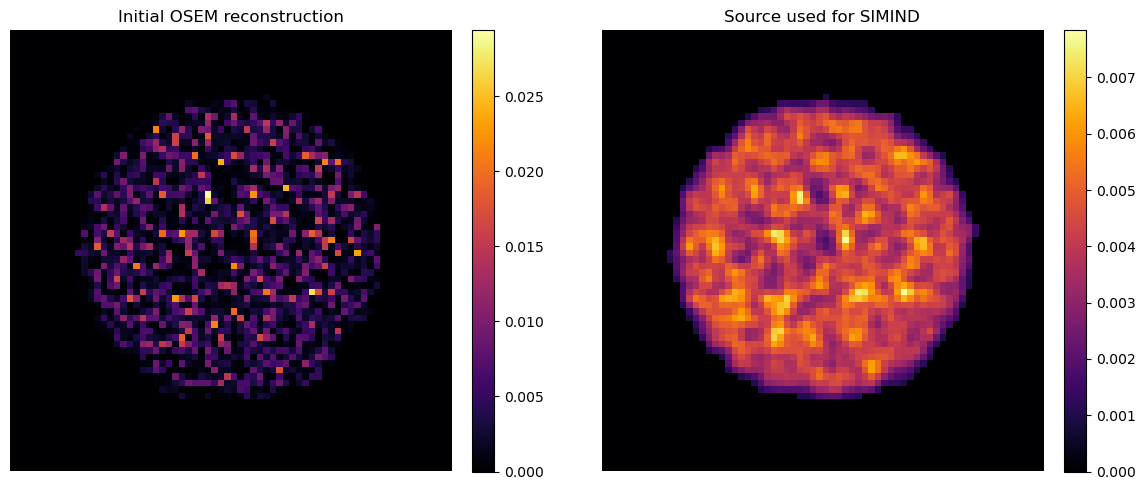

In [28]:
initial_reconstruction = spect.ImageData(str(recon_dir / f"initial_recon_{name_prefix}.hv")) / icf_osem

source_for_simind = initial_reconstruction.clone()

gaussian_filter = spect.SeparableGaussianImageFilter()
gaussian_filter.set_fwhms((9, 9, 9))
gaussian_filter.apply(source_for_simind)

source_arr = source_for_simind.as_array()
threshold = 0.1 * source_arr.max()
source_arr[source_arr < threshold] = 0
source_for_simind.fill(source_arr) / icf_osem

source_for_simind.write(str(recon_dir / f"source_for_simind_{name_prefix}"))

idx = (55, slice(30, 98), slice(30, 98))

vmax = max(
    np.max(initial_reconstruction.as_array()[idx]),
    np.max(source_for_simind.as_array()[idx])
)

utils.display_arr(
    arr_3d=[
        initial_reconstruction.as_array(),
        source_for_simind.as_array()
    ],
    idx=idx,
    #vmax=[vmax, vmax],
    titles=[
        "Initial OSEM reconstruction",
        "Source used for SIMIND"
    ]
)

In [29]:
# Lu-177 photopeak window
window_lower = [187.2]   # keV
#window_lower = [126.45]   # keV
window_upper = [228.8]   # keV
#window_upper = [154.55]   # keV
scatter_orders = [0]
time_per_proj = 10 #sec

output_dir = recon_dir / "sim_output"
output_dir.mkdir(parents=True, exist_ok=True)

config_file = Path("/home/jovyan/sirf-demo/.packages/Discovery670_lu177.yaml")
#config_file = Path("/home/jovyan/sirf-demo/.packages/Discovery670_tc99m.yaml")

simind = StirSimindAdaptor(
    config_source=str(config_file),
    output_dir=str(output_dir),
    output_prefix="lu177_sim",
    #output_prefix="tc99m_sim",
    photon_multiplier=0.01,
)

simind.set_source(source_for_simind)
simind.set_mu_map(attenuation_map)

simind.add_config_value(25, np.sum(source_for_simind.as_array()) * time_per_proj)

simind.set_energy_windows(
    lower_bounds=window_lower,
    upper_bounds=window_upper,
    scatter_orders=scatter_orders,
)

simind.add_runtime_switch("FI", "lu177")
#simind.add_runtime_switch("FI", "tc99m")
simind.add_runtime_switch("CC", "ge-megp")
simind.add_runtime_switch("RR", 12345)

outputs = simind.run()

# Inspect the returned output mapping in case filenames differ
print(outputs)

INFO: Running SIMIND: simind lu177_sim lu177_sim /NN:0.01/FI:lu177/CC:ge-megp/RR:12345/PX:0.4420000076293945


 



              SIMIND Monte Carlo Simulation Program    V8.0  
------------------------------------------------------------------------------
 Phantom S : h2o       Crystal...: nai       InputFile.: lu177_sim         
 Phantom B : bone      BackScatt.: pmt       OutputFile: lu177_sim         
 Collimator: pb_sb2    SourceRout: smap      SourceImg.: lu177_sim_src     
 Cover.....: al        ScoreRout.: scattwin  DensityImg: lu177_sim_dns     
------------------------------------------------------------------------------
 PhotonEnergy.......: 208          lu177     PhotonsPerProj....: 159787         
 EnergyResolution...: 12           Spectra   Activity..........: 3077.6         
 MaxScatterOrder....: 3            ge-megp   DetectorLenght....: 20             
 DetectorWidth......: 27           SPECT     DetectorHeight....: 0.9525         
 UpperEneWindowTresh: 312          x-rays    Distance to det...: 11.979         
 LowerEneWindowTresh: 104          Random    ShiftSource X.....: 0

INFO: Converted 120 radii from orbit file lu177_sim.cor
INFO: Successfully converted /home/jovyan/sirf-demo/icf_calculation/lu177_128/recons/osem_mc/sim_output/lu177_sim_air_w1.h00 to /home/jovyan/sirf-demo/icf_calculation/lu177_128/recons/osem_mc/sim_output/lu177_sim_air_w1.hs
INFO: Converted 120 radii from orbit file lu177_sim.cor
INFO: Successfully converted /home/jovyan/sirf-demo/icf_calculation/lu177_128/recons/osem_mc/sim_output/lu177_sim_sca_w1.h00 to /home/jovyan/sirf-demo/icf_calculation/lu177_128/recons/osem_mc/sim_output/lu177_sim_sca_w1.hs
INFO: Converted 120 radii from orbit file lu177_sim.cor
INFO: Successfully converted /home/jovyan/sirf-demo/icf_calculation/lu177_128/recons/osem_mc/sim_output/lu177_sim_sca_w2.h00 to /home/jovyan/sirf-demo/icf_calculation/lu177_128/recons/osem_mc/sim_output/lu177_sim_sca_w2.hs
INFO: Converted 120 radii from orbit file lu177_sim.cor
INFO: Successfully converted /home/jovyan/sirf-demo/icf_calculation/lu177_128/recons/osem_mc/sim_output/lu1

------------------------------------------------------------------------------
 GENERAL DATA
 keV/channel........: 1                      CutoffEnergy......: 0              
 Photons/Bq.........: 0.2264                 StartingAngle.....: 0              
 CameraOffset X.....: 0                      CoverThickness....: 0.1            
 CameraOffset Y.....: 0                      BackscatterThickn.: 0              
 MatrixSize I.......: 128                    IntrinsicResolut..: 0.55           
 MatrixSize J.......: 128                    AcceptanceAngle...: 4.02754        
 Emission type......: 2                      Initial Weight....: 4360.57054     
 NN ScalingFactor...: 0.01                   Energy Channels...: 512            
                                                                              
 SPECT DATA
 RotationMode.......: 360                    Nr of Projections.: 120            
 RotationAngle......: 3                      Projection.[start]: 1              
 Orbit

(<Figure size 1200x500 with 4 Axes>, array([<Axes: >, <Axes: >], dtype=object))

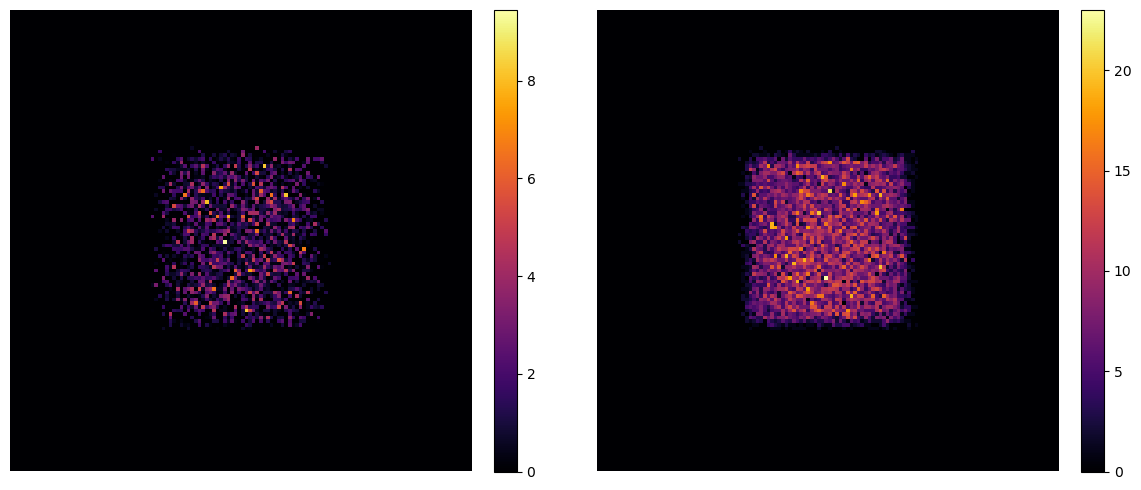

In [31]:
test_arr = spect.AcquisitionData(str(output_dir / "lu177_sim_sca_w1.hs")).as_array()[0]
tomo_arr = spect.AcquisitionData(str(tomo_em)).as_array()[0]

utils.display_arr(
    arr_3d=[test_arr, tomo_arr],
    idx=(slice(None),60,slice(None))
)

In [32]:
tomo_mc_sca = output_dir / "lu177_sim_sca_w1.hs"
#tomo_mc_sca = output_dir / "tc99m_sim_sca_w1.hs"

# Load scatter-corrected projection data
acquisition_data = spect.AcquisitionData(str(tomo_em))
acq_data_sca = spect.AcquisitionData(str(tomo_mc_sca))

# Create the SPECT system matrix
acq_model_matrix = spect.SPECTUBMatrix()

# Optionally cache projection views to speed up reconstruction
acq_model_matrix.set_keep_all_views_in_cache(keep_views_in_cache)


# -------------------------------------------------------------------------
# Attenuation correction
# -------------------------------------------------------------------------

# The attenuation map is currently flipped to account for the image
# orientation expected by this STIR configuration.
flipped_attenuation_map = attenuation_map.clone()
flipped_attenuation_map.fill(
    np.flip(attenuation_map.as_array(), axis=2)
)

acq_model_matrix.set_attenuation_image(flipped_attenuation_map)


# -------------------------------------------------------------------------
# Acquisition model
# -------------------------------------------------------------------------

am = spect.AcquisitionModelUsingMatrix(acq_model_matrix)

# Configure the model for the measured projections and image geometry
am.set_up(acquisition_data, initial_image)
am.set_additive_term(acq_data_sca)

# Create the Poisson log-likelihood objective function
obj_fun = spect.make_Poisson_loglikelihood(acquisition_data)

# Associate it with the SPECT acquisition model
obj_fun.set_acquisition_model(am)

# Create the image that will be updated during reconstruction
reconstructed_image = initial_image.clone()

# Configure the OSEM reconstructor
recon = spect.OSMAPOSLReconstructor()

recon.set_num_subiterations(100)
recon.set_num_subsets(2)

# Save intermediate reconstruction results
recon.set_save_interval(save_interval)
recon.enable_output()
recon.set_output_filename_prefix(str(recon_dir / f"{name_prefix}_{recon_type}"))

# Set the objective function
recon.set_objective_function(obj_fun)

# Initialise and run the reconstruction
recon.set_up(reconstructed_image)
recon.reconstruct(reconstructed_image)

icf_osem_mc = np.sum(reconstructed_image.as_array() * mask_arr) / np.sum(gt_act_arr * mask_arr) #cnts/MBq
print("ICF (OSEM MC) =", icf_osem_mc) #cnts/MBq

ICF (OSEM MC) = 123.46838


In [33]:
# Reconstruction output
recon_type = "osem_rm_mc"
recon_dir = sim_dir / "recons" / recon_type
recon_dir.mkdir(parents=True, exist_ok=True)

# Load scatter-corrected projection data
acquisition_data = spect.AcquisitionData(str(tomo_em))
acq_data_sca = spect.AcquisitionData(str(tomo_sca))

# Create the SPECT system matrix
acq_model_matrix = spect.SPECTUBMatrix()

# Optionally cache projection views to speed up reconstruction
acq_model_matrix.set_keep_all_views_in_cache(keep_views_in_cache)


# -------------------------------------------------------------------------
# Attenuation correction
# -------------------------------------------------------------------------

# The attenuation map is currently flipped to account for the image
# orientation expected by this STIR configuration.
flipped_attenuation_map = attenuation_map.clone()
flipped_attenuation_map.fill(
    np.flip(attenuation_map.as_array(), axis=2)
)

acq_model_matrix.set_attenuation_image(flipped_attenuation_map)

# -------------------------------------------------------------------------
# Resolution modelling
# -------------------------------------------------------------------------

acq_model_matrix.set_resolution_model(
    float(sigma_0),
    float(slope),
    full_3D=False
)

# -------------------------------------------------------------------------
# Acquisition model
# -------------------------------------------------------------------------

am = spect.AcquisitionModelUsingMatrix(acq_model_matrix)

# Configure the model for the measured projections and image geometry
am.set_up(acquisition_data, initial_image)
am.set_additive_term(acq_data_sca)

# Create the Poisson log-likelihood objective function
obj_fun = spect.make_Poisson_loglikelihood(acquisition_data)

# Associate it with the SPECT acquisition model
obj_fun.set_acquisition_model(am)

# Create the image that will be updated during reconstruction
initial_reconstruction = initial_image.clone()

# Configure the OSEM reconstructor
recon = spect.OSMAPOSLReconstructor()

recon.set_num_subiterations(60)
recon.set_num_subsets(12)

# Set the objective function
recon.set_objective_function(obj_fun)

# Initialise and run the reconstruction
recon.set_up(initial_reconstruction)
recon.reconstruct(initial_reconstruction)

initial_reconstruction.write(str(recon_dir / f"initial_recon_{name_prefix}"))



(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': 'Initial OSEM reconstruction'}>,
        <Axes: title={'center': 'Source used for SIMIND'}>], dtype=object))

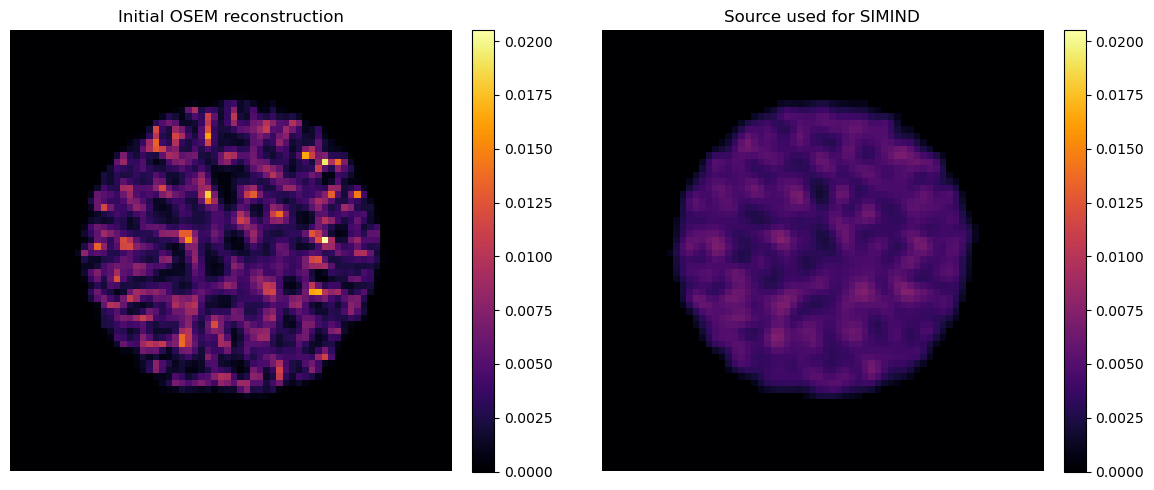

In [34]:
initial_reconstruction = spect.ImageData(str(recon_dir / f"initial_recon_{name_prefix}.hv")) / icf_osem_rm

source_for_simind = initial_reconstruction.clone()

gaussian_filter = spect.SeparableGaussianImageFilter()
gaussian_filter.set_fwhms((9, 9, 9))
gaussian_filter.apply(source_for_simind)

source_arr = source_for_simind.as_array()
threshold = 0.1 * source_arr.max()
source_arr[source_arr < threshold] = 0
source_for_simind.fill(source_arr)

source_for_simind.write(str(recon_dir / f"source_for_simind_{name_prefix}"))

idx = (55, slice(30, 98), slice(30, 98))

vmax = max(
    np.max(initial_reconstruction.as_array()[idx]),
    np.max(source_for_simind.as_array()[idx])
)

utils.display_arr(
    arr_3d=[
        initial_reconstruction.as_array(),
        source_for_simind.as_array()
    ],
    idx=idx,
    vmax=[vmax, vmax],
    titles=[
        "Initial OSEM reconstruction",
        "Source used for SIMIND"
    ]
)

In [35]:
# Lu-177 photopeak window
window_lower = [187.2]   # keV
#window_lower = [126.45]   # keV
window_upper = [228.8]   # keV
#window_upper = [154.55]   # keV
scatter_orders = [0]
time_per_proj = 10 #sec

output_dir = recon_dir / "sim_output"
output_dir.mkdir(parents=True, exist_ok=True)

#config_file = Path("/home/jovyan/sirf-demo/.packages/Discovery670_lu177.yaml")
config_file = Path("/home/jovyan/sirf-demo/.packages/Discovery670_tc99m.yaml")

simind = StirSimindAdaptor(
    config_source=str(config_file),
    output_dir=str(output_dir),
    output_prefix="lu177_sim",
    #output_prefix="tc99m_sim",
    photon_multiplier=0.01,
)

simind.set_source(source_for_simind)
simind.set_mu_map(attenuation_map)

simind.add_config_value(25, np.sum(source_for_simind.as_array()) * time_per_proj)

simind.set_energy_windows(
    lower_bounds=window_lower,
    upper_bounds=window_upper,
    scatter_orders=scatter_orders,
)

simind.add_runtime_switch("FI", "lu177")
simind.add_runtime_switch("CC", "ge-megp")
simind.add_runtime_switch("RR", 12345)

outputs = simind.run()

# Inspect the returned output mapping in case filenames differ
print(outputs)

INFO: Running SIMIND: simind lu177_sim lu177_sim /NN:0.01/FI:lu177/CC:ge-megp/RR:12345/PX:0.4420000076293945


 



              SIMIND Monte Carlo Simulation Program    V8.0  
------------------------------------------------------------------------------
 Phantom S : h2o       Crystal...: nai       InputFile.: lu177_sim         
 Phantom B : bone      BackScatt.: pmt       OutputFile: lu177_sim         
 Collimator: pb_sb2    SourceRout: smap      SourceImg.: lu177_sim_src     
 Cover.....: al        ScoreRout.: scattwin  DensityImg: lu177_sim_dns     
------------------------------------------------------------------------------
 PhotonEnergy.......: 140          lu177     PhotonsPerProj....: 176849         
 EnergyResolution...: 12           Spectra   Activity..........: 3088.7         
 MaxScatterOrder....: 3            ge-megp   DetectorLenght....: 20             
 DetectorWidth......: 27           SPECT     DetectorHeight....: 0.9525         
 UpperEneWindowTresh: 210          x-rays    Distance to det...: 11.979         
 LowerEneWindowTresh: 70           Random    ShiftSource X.....: 0

INFO: Converted 120 radii from orbit file lu177_sim.cor
INFO: Successfully converted /home/jovyan/sirf-demo/icf_calculation/lu177_128/recons/osem_rm_mc/sim_output/lu177_sim_air_w1.h00 to /home/jovyan/sirf-demo/icf_calculation/lu177_128/recons/osem_rm_mc/sim_output/lu177_sim_air_w1.hs
INFO: Converted 120 radii from orbit file lu177_sim.cor
INFO: Successfully converted /home/jovyan/sirf-demo/icf_calculation/lu177_128/recons/osem_rm_mc/sim_output/lu177_sim_sca_w1.h00 to /home/jovyan/sirf-demo/icf_calculation/lu177_128/recons/osem_rm_mc/sim_output/lu177_sim_sca_w1.hs
INFO: Converted 120 radii from orbit file lu177_sim.cor
INFO: Successfully converted /home/jovyan/sirf-demo/icf_calculation/lu177_128/recons/osem_rm_mc/sim_output/lu177_sim_sca_w2.h00 to /home/jovyan/sirf-demo/icf_calculation/lu177_128/recons/osem_rm_mc/sim_output/lu177_sim_sca_w2.hs
INFO: Converted 120 radii from orbit file lu177_sim.cor
INFO: Successfully converted /home/jovyan/sirf-demo/icf_calculation/lu177_128/recons/osem

------------------------------------------------------------------------------
 GENERAL DATA
 keV/channel........: 0.5                    CutoffEnergy......: 0              
 Photons/Bq.........: 0.2264                 StartingAngle.....: 0              
 CameraOffset X.....: 0                      CoverThickness....: 0.1            
 CameraOffset Y.....: 0                      BackscatterThickn.: 0              
 MatrixSize I.......: 128                    IntrinsicResolut..: 0.55           
 MatrixSize J.......: 128                    AcceptanceAngle...: 4.02754        
 Emission type......: 2                      Initial Weight....: 3954.08231     
 NN ScalingFactor...: 0.01                   Energy Channels...: 512            
                                                                              
 SPECT DATA
 RotationMode.......: 360                    Nr of Projections.: 120            
 RotationAngle......: 3                      Projection.[start]: 1              
 Orbit

In [36]:
tomo_mc_sca = output_dir / "lu177_sim_sca_w1.hs"
#tomo_mc_sca = output_dir / "tc99m_sim_sca_w1.hs"

# Load scatter-corrected projection data
acquisition_data = spect.AcquisitionData(str(tomo_em))
acq_data_sca = spect.AcquisitionData(str(tomo_mc_sca))

# Create the SPECT system matrix
acq_model_matrix = spect.SPECTUBMatrix()

# Optionally cache projection views to speed up reconstruction
acq_model_matrix.set_keep_all_views_in_cache(keep_views_in_cache)


# -------------------------------------------------------------------------
# Attenuation correction
# -------------------------------------------------------------------------

# The attenuation map is currently flipped to account for the image
# orientation expected by this STIR configuration.
flipped_attenuation_map = attenuation_map.clone()
flipped_attenuation_map.fill(
    np.flip(attenuation_map.as_array(), axis=2)
)

acq_model_matrix.set_attenuation_image(flipped_attenuation_map)

# -------------------------------------------------------------------------
# Resolution modelling
# -------------------------------------------------------------------------

acq_model_matrix.set_resolution_model(
    float(sigma_0),
    float(slope),
    full_3D=False
)

# -------------------------------------------------------------------------
# Acquisition model
# -------------------------------------------------------------------------

am = spect.AcquisitionModelUsingMatrix(acq_model_matrix)

# Configure the model for the measured projections and image geometry
am.set_up(acquisition_data, initial_image)
am.set_additive_term(acq_data_sca)

# Create the Poisson log-likelihood objective function
obj_fun = spect.make_Poisson_loglikelihood(acquisition_data)

# Associate it with the SPECT acquisition model
obj_fun.set_acquisition_model(am)

# Create the image that will be updated during reconstruction
reconstructed_image = initial_image.clone()

# Configure the OSEM reconstructor
recon = spect.OSMAPOSLReconstructor()

recon.set_num_subiterations(100)
recon.set_num_subsets(2)

# Save intermediate reconstruction results
recon.set_save_interval(save_interval)
recon.enable_output()
recon.set_output_filename_prefix(str(recon_dir / f"{name_prefix}_{recon_type}"))

# Set the objective function
recon.set_objective_function(obj_fun)

# Initialise and run the reconstruction
recon.set_up(reconstructed_image)
recon.reconstruct(reconstructed_image)

icf_osem_rm_mc = np.sum(reconstructed_image.as_array() * mask_arr) / np.sum(gt_act_arr * mask_arr) #cnts/MBq
print("ICF (OSEM-RM MC) =", icf_osem_rm_mc) #cnts/MBq



ICF (OSEM-RM MC) = 122.46166


In [37]:
print("Lu177")
print("ICF (OSEM) =", icf_osem)
print("ICF (OSEM-RM) =", icf_osem_rm)
print("ICF (OSEM MC) =", icf_osem_mc)
print("ICF (OSEM-RM MC) =", icf_osem_rm_mc)

Lu177
ICF (OSEM) = 109.264725
ICF (OSEM-RM) = 109.16247
ICF (OSEM MC) = 123.46838
ICF (OSEM-RM MC) = 122.46166


In [ ]:
print("Tc99m")
print("ICF (OSEM) =", icf_osem)
print("ICF (OSEM-RM) =", icf_osem_rm)
print("ICF (OSEM MC) =", icf_osem_mc)
print("ICF (OSEM-RM MC) =", icf_osem_rm_mc)

Tc99m
ICF (OSEM) = 1485.8441
ICF (OSEM-RM) = 1485.9268
ICF (OSEM MC) = 1567.4679
ICF (OSEM-RM MC) = 1573.4701


0.004317544
Lu-177 314.73157
Tc-99m 311.64062


(<Figure size 1200x500 with 4 Axes>, array([<Axes: >, <Axes: >], dtype=object))

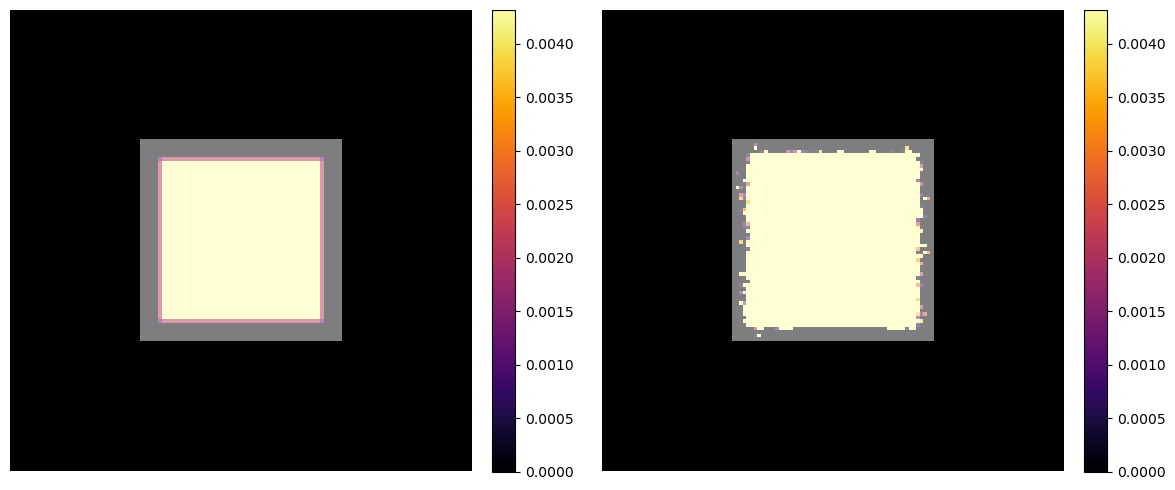

In [10]:
idx=(slice(None), 60, slice(None))
vmax = np.max(gt_lu_act_arr[idx])

print(vmax)
print("Lu-177", np.sum(gt_lu_act_arr*mask_arr))
print("Tc-99m", np.sum(gt_tc_act_arr*mask_arr))

utils.superimpose_arr(
    img_3d=[gt_tc_act_arr, recon_tc_osem_rm],
    ct_3d=[mask_arr, mask_arr],
    idx=idx,
    img_vmax=vmax
)